# Ley de Malus Generalizada: Simulación Clásica y Cuántica

## Régimen Clásico (Esfera de Poincaré) y Régimen Cuántico (Esfera de Bloch)

Este cuaderno implementa dos clases:
- **`ClassicalMalus`**: Simula la ley de Malus generalizada para haces parcialmente coherentes con polarización elíptica.
- **`QuantumMalus`**: Simula la ley de Malus cuántica para qubits de polarización (fotones individuales).

Ambas clases incluyen visualización de la probabilidad/intensidad como función del ángulo azimutal $\phi$, y las trayectorias de los estados sobre la esfera de Poincaré/Bloch.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm
from matplotlib.lines import Line2D
import matplotlib.gridspec as gridspec

plt.rcParams.update({
    'figure.figsize': (14, 6),
    'font.size': 12,
    'axes.labelsize': 13,
    'axes.titlesize': 14,
    'legend.fontsize': 10,
    'figure.dpi': 120
})


def add_sweep_arrows(ax, s1, s2, s3, phi_arr, n_arrows=3, color='black',
                     arrow_len=0.30, lw=2.2):
    """
    Dibuja flechas tangentes sobre la trayectoria (círculo de χ constante)
    en la esfera de Poincaré/Bloch, indicando el SENTIDO en que se barre al
    aumentar φ.

    Devuelve una cadena con el sentido de giro VISTO DESDE EL POLO +S₃
    ('antihorario', 'horario' o 'sin barrido'), pensada para la leyenda.

    El sentido se obtiene del signo de la componente S₃ de r × (dr/dφ):
        cross_z = s1·ṡ₂ − s2·ṡ₁ .
    Para esta familia de trayectorias cross_z = 2·cos²(2χ_P) ≥ 0, de modo
    que el barrido es SIEMPRE antihorario alrededor de +S₃ (independiente del
    signo de χ_P); en los polos (χ_P = ±45°, polarización circular) la
    trayectoria degenera a un punto y no hay barrido.
    """
    s1 = np.asarray(s1, float); s2 = np.asarray(s2, float); s3 = np.asarray(s3, float)
    ds1 = np.gradient(s1, phi_arr)
    ds2 = np.gradient(s2, phi_arr)
    ds3 = np.gradient(s3, phi_arr)

    # ¿La trayectoria tiene radio apreciable? (en los polos degenera a un punto)
    radio = np.hypot(s1 - s1.mean(), s2 - s2.mean()).max()
    if radio < 1e-6:
        return 'sin barrido (polarización circular)'

    # Índices equiespaciados, desfasados para no caer justo en φ=0
    n = len(phi_arr)
    base = np.linspace(0, n - 1, n_arrows, endpoint=False)
    idx = ((base + n / (2 * n_arrows)).astype(int)) % n
    for i in idx:
        t = np.array([ds1[i], ds2[i], ds3[i]])
        if np.linalg.norm(t) < 1e-12:
            continue
        ax.quiver(s1[i], s2[i], s3[i], t[0], t[1], t[2],
                  length=arrow_len, normalize=True, color=color, lw=lw,
                  arrow_length_ratio=0.5, zorder=6)

    cross_z = float(np.mean(s1 * ds2 - s2 * ds1))
    return 'antihorario' if cross_z > 0 else 'horario'

---
## 1. Régimen Clásico: Ley de Malus Generalizada

### 1.1 Marco teórico

Un haz parcialmente coherente se describe mediante la **matriz de coherencia de Wolf**, que admite la descomposición:

$$J = \frac{I_0(1-\mathcal{P})}{2}\mathbb{I} + I_0\mathcal{P}\;|\psi_{\text{pol}}\rangle\langle\psi_{\text{pol}}|$$

donde $\mathcal{P} \in [0,1]$ es el grado de polarización.

Cada estado de polarización pura se representa en la **esfera de Poincaré** con vector de Stokes unitario:

$$\hat{s} = \begin{pmatrix} \cos 2\chi \cos 2\alpha \\ \cos 2\chi \sin 2\alpha \\ \sin 2\chi \end{pmatrix}$$

La **ley de Malus completamente generalizada** es:

$$\boxed{I = \frac{I_0}{2}\left[1 + \mathcal{P}\left(\cos 2\chi_{\text{in}}\cos 2\chi_P\cos 2\phi + \sin 2\chi_{\text{in}}\sin 2\chi_P\right)\right]}$$

o equivalentemente: $I = \frac{I_0}{2}[1 + \mathcal{P}\cos\Theta]$, donde $\Theta$ es la distancia angular en la esfera de Poincaré.

### 1.2 Forma del Haversine

$$I = I_0\left[\frac{1+\mathcal{P}}{2} - \mathcal{P}\left(\sin^2(\chi_{\text{in}}-\chi_P) + \cos 2\chi_{\text{in}}\cos 2\chi_P\sin^2\phi\right)\right]$$

In [2]:
class ClassicalMalus:
    """
    Simula la ley de Malus generalizada para haces parcialmente coherentes
    con polarización elíptica arbitraria.
    
    Parámetros
    ----------
    alpha_in : float
        Ángulo de orientación del estado incidente (rad).
    chi_in : float
        Ángulo de elipticidad del estado incidente (rad), en [-pi/4, pi/4].
    alpha_P : float
        Ángulo de orientación del polarizador (rad).
    chi_P : float
        Ángulo de elipticidad del polarizador (rad), en [-pi/4, pi/4].
    P_degree : float
        Grado de polarización del haz incidente, en [0, 1].
    I0 : float
        Intensidad total del haz incidente.
    """
    
    def __init__(self, alpha_in=0.0, chi_in=0.0, alpha_P=0.0, chi_P=0.0,
                 P_degree=1.0, I0=1.0):
        self.alpha_in = alpha_in
        self.chi_in = chi_in
        self.alpha_P = alpha_P
        self.chi_P = chi_P
        self.P_degree = P_degree
        self.I0 = I0
    
    def stokes_vector(self, alpha, chi):
        """Vector de Stokes unitario en la esfera de Poincaré."""
        s1 = np.cos(2*chi) * np.cos(2*alpha)
        s2 = np.cos(2*chi) * np.sin(2*alpha)
        s3 = np.sin(2*chi)
        return np.array([s1, s2, s3])
    
    def dot_product(self, phi):
        """Producto escalar entre vectores de Stokes, con ángulo azimutal relativo phi."""
        return (np.cos(2*self.chi_in) * np.cos(2*self.chi_P) * np.cos(2*phi)
                + np.sin(2*self.chi_in) * np.sin(2*self.chi_P))
    
    def intensity(self, phi):
        """Intensidad transmitida (Ley de Malus generalizada)."""
        return (self.I0 / 2) * (1 + self.P_degree * self.dot_product(phi))
    
    def haversine_intensity(self, phi):
        """Intensidad en forma de haversine (equivalente)."""
        hav_chi = np.sin(self.chi_in - self.chi_P)**2
        hav_phi = np.cos(2*self.chi_in) * np.cos(2*self.chi_P) * np.sin(phi)**2
        return self.I0 * ((1 + self.P_degree) / 2 - self.P_degree * (hav_chi + hav_phi))
    
    def poincare_distance(self, phi):
        """Distancia angular Theta en la esfera de Poincaré."""
        cos_theta = self.dot_product(phi)
        cos_theta = np.clip(cos_theta, -1, 1)
        return np.arccos(cos_theta)
    
    def visibility(self):
        """Visibilidad de la modulación."""
        B = self.P_degree * abs(np.cos(2*self.chi_in) * np.cos(2*self.chi_P))
        A = 1 + self.P_degree * np.sin(2*self.chi_in) * np.sin(2*self.chi_P)
        return B / A if A != 0 else 0
    
    def trajectory_on_poincare(self, phi_array):
        """
        Trayectoria del estado del polarizador sobre la esfera de Poincaré
        cuando se rota un ángulo phi (manteniendo chi_P fijo).
        """
        s1 = np.cos(2*self.chi_P) * np.cos(2*(self.alpha_P + phi_array))
        s2 = np.cos(2*self.chi_P) * np.sin(2*(self.alpha_P + phi_array))
        s3 = np.sin(2*self.chi_P) * np.ones_like(phi_array)
        return s1, s2, s3
    
    def plot_intensity(self, N_points=500):
        """Grafica la intensidad vs phi."""
        phi = np.linspace(0, 2*np.pi, N_points)
        I = self.intensity(phi)
        I_hav = self.haversine_intensity(phi)
        
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        
        # Cartesiano
        axes[0].plot(np.degrees(phi), I / self.I0, 'b-', lw=2, label='Poincaré')
        axes[0].plot(np.degrees(phi), I_hav / self.I0, 'r--', lw=1.5, label='Haversine', alpha=0.7)
        axes[0].set_xlabel(r'$\phi$ (grados)')
        axes[0].set_ylabel(r'$I / I_0$')
        axes[0].set_title(
            rf'Ley de Malus Clásica: $\chi_{{in}}={np.degrees(self.chi_in):.0f}°$, '
            rf'$\chi_P={np.degrees(self.chi_P):.0f}°$, $\mathcal{{P}}={self.P_degree:.1f}$')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)
        axes[0].set_xlim(0, 360)
        axes[0].set_ylim(bottom=0)
        
        # Polar
        ax_pol = fig.add_subplot(122, projection='polar')
        axes[1].set_visible(False)
        ax_pol.plot(phi, I / self.I0, 'b-', lw=2)
        ax_pol.set_title(r'$I(\phi)/I_0$ — Polar', pad=20)
        ax_pol.set_rticks([0.25, 0.5, 0.75, 1.0])
        
        plt.tight_layout()
        plt.show()
    
    def plot_poincare_sphere(self, N_points=500):
        """Grafica la esfera de Poincaré con el estado incidente y la trayectoria del polarizador."""
        phi_arr = np.linspace(0, 2*np.pi, N_points)
        
        fig = plt.figure(figsize=(9, 9))
        ax = fig.add_subplot(111, projection='3d')
        
        # Esfera semitransparente
        u = np.linspace(0, 2*np.pi, 60)
        v = np.linspace(0, np.pi, 40)
        xs = np.outer(np.cos(u), np.sin(v))
        ys = np.outer(np.sin(u), np.sin(v))
        zs = np.outer(np.ones_like(u), np.cos(v))
        ax.plot_surface(xs, ys, zs, alpha=0.08, color='lightblue', edgecolor='lightblue', linewidth=0.1)
        
        # Ejes
        ax.plot([-1.3, 1.3], [0, 0], [0, 0], 'k-', lw=0.5, alpha=0.3)
        ax.plot([0, 0], [-1.3, 1.3], [0, 0], 'k-', lw=0.5, alpha=0.3)
        ax.plot([0, 0], [0, 0], [-1.3, 1.3], 'k-', lw=0.5, alpha=0.3)
        ax.text(1.4, 0, 0, r'$S_1$', fontsize=12)
        ax.text(0, 1.4, 0, r'$S_2$', fontsize=12)
        ax.text(0, 0, 1.4, r'$S_3$', fontsize=12)
        
        # Estado incidente (punto fijo)
        s_in = self.stokes_vector(self.alpha_in, self.chi_in)
        ax.scatter(*s_in, color='red', s=150, zorder=5, edgecolors='darkred', linewidth=1.5,
                   label=rf'Estado incidente ($\alpha={np.degrees(self.alpha_in):.0f}°$, $\chi={np.degrees(self.chi_in):.0f}°$)')
        
        # Trayectoria del polarizador (varía phi)
        s1_traj, s2_traj, s3_traj = self.trajectory_on_poincare(phi_arr)
        I_traj = self.intensity(phi_arr) / self.I0
        
        scatter = ax.scatter(s1_traj, s2_traj, s3_traj, c=I_traj, cmap='viridis',
                            s=8, alpha=0.8, zorder=3)
        
        # Sentido de barrido: flechas tangentes en la dirección de phi creciente
        sentido = add_sweep_arrows(ax, s1_traj, s2_traj, s3_traj, phi_arr,
                                   color='black', n_arrows=3)
        
        # Polarizador en phi=0
        s_P0 = self.stokes_vector(self.alpha_P, self.chi_P)
        ax.scatter(*s_P0, color='lime', s=150, zorder=5, marker='D', edgecolors='darkgreen', linewidth=1.5,
                   label=rf'Polarizador $\phi=0$ ($\chi_P={np.degrees(self.chi_P):.0f}°$)')
        
        # Estado ortogonal
        s_ort = self.stokes_vector(self.alpha_in + np.pi/2, -self.chi_in)
        ax.scatter(*s_ort, color='blue', s=80, zorder=5, marker='x', linewidth=2,
                   label='Estado ortogonal')
        
        # Geodésica entre estado incidente y polarizador en phi=0
        t = np.linspace(0, 1, 100)
        geodesic = np.outer(1-t, s_in) + np.outer(t, s_P0)
        norms = np.linalg.norm(geodesic, axis=1, keepdims=True)
        geodesic = geodesic / norms
        ax.plot(geodesic[:,0], geodesic[:,1], geodesic[:,2], 'r--', lw=1.5, alpha=0.6)
        
        cbar = plt.colorbar(scatter, ax=ax, shrink=0.6, pad=0.1)
        cbar.set_label(r'$I/I_0$ (Transmitancia)')
        
        ax.set_title(rf'Esfera de Poincaré — $\mathcal{{P}}={self.P_degree:.1f}$', fontsize=14, pad=20)
        # Leyenda: añadimos una entrada con el sentido de barrido de phi
        handles, labels = ax.get_legend_handles_labels()
        handles.append(Line2D([0], [0], color='black', lw=2.2, marker=r'$\rightarrow$',
                              markersize=12, linestyle='-'))
        labels.append(rf'Barrido $\phi\!\uparrow$: {sentido} (visto desde $+S_3$)')
        ax.legend(handles, labels, loc='lower left', fontsize=9)
        ax.set_xlim([-1.2, 1.2])
        ax.set_ylim([-1.2, 1.2])
        ax.set_zlim([-1.2, 1.2])
        ax.set_box_aspect([1,1,1])
        
        plt.tight_layout()
        plt.show()
    
    def plot_complete(self, N_points=500):
        """Genera ambas gráficas: intensidad y esfera de Poincaré."""
        self.plot_intensity(N_points)
        self.plot_poincare_sphere(N_points)

### 1.3 Caso 1: Ley de Malus clásica ($\chi_{in}=\chi_P=0$, $\mathcal{P}=1$)

Ambos lineales, completamente polarizado: $I = I_0\cos^2\phi$.

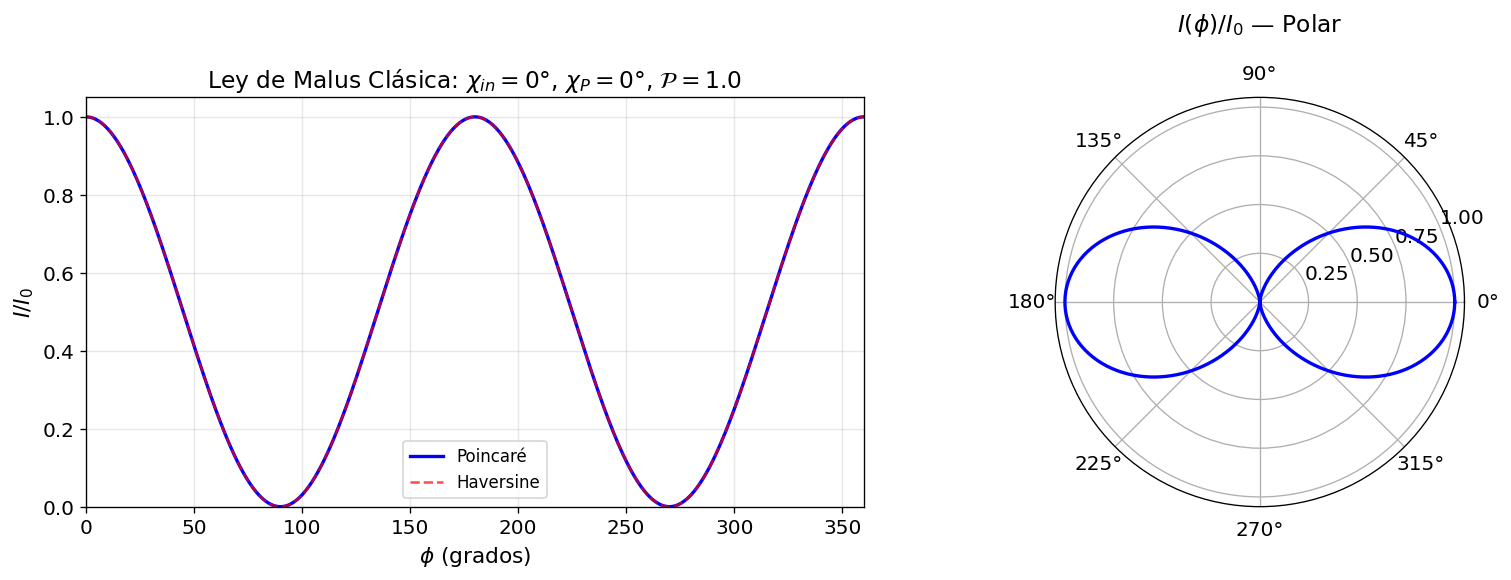

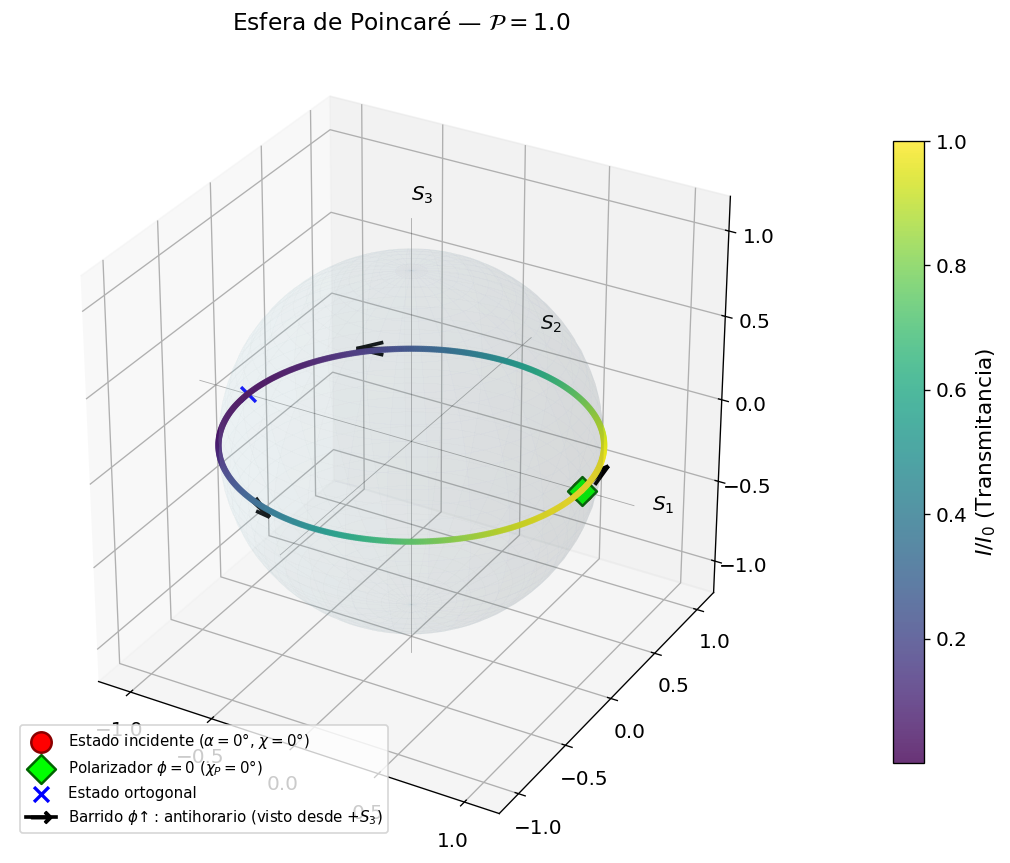

In [3]:
malus_clasico = ClassicalMalus(alpha_in=0, chi_in=0, alpha_P=0, chi_P=0,
                                P_degree=1.0, I0=1.0)
malus_clasico.plot_complete()

### 1.4 Caso 2: Polarización parcial lineal ($\chi_{in}=\chi_P=0$, $\mathcal{P}=0.6$)

La curva oscila entre $I_{\max}$ y $I_{\min} > 0$. La visibilidad es $\mathcal{V} = \mathcal{P}$.

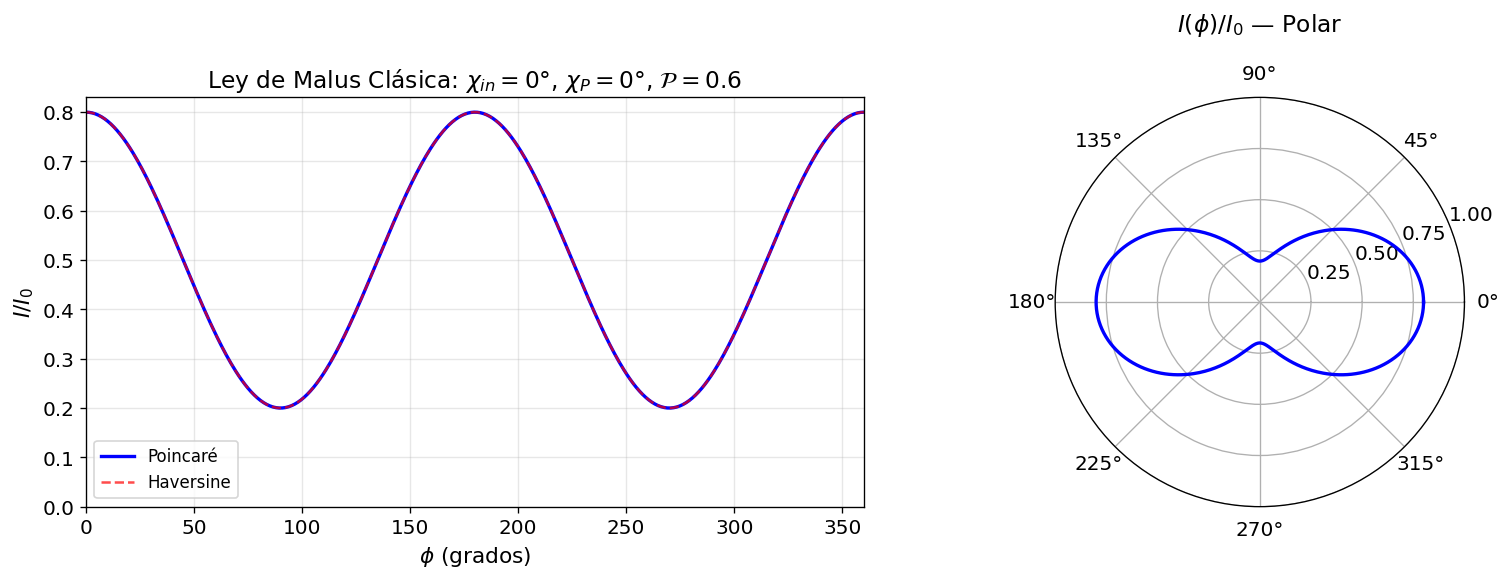

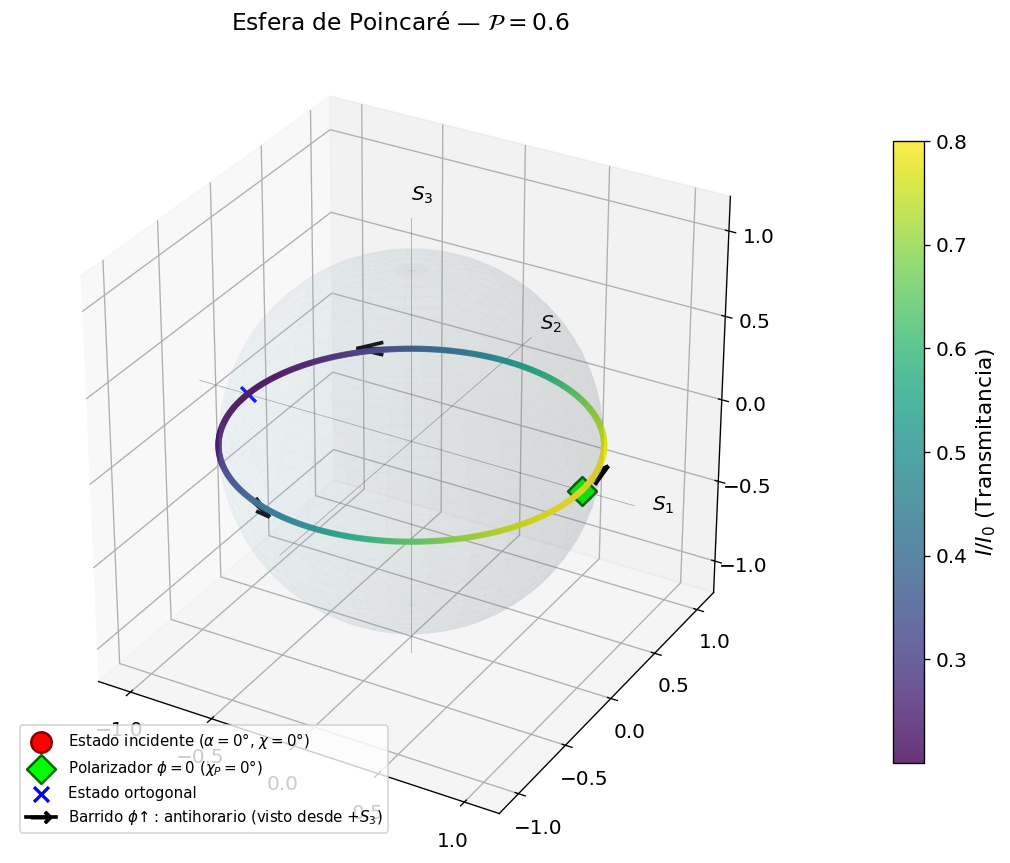

Visibilidad: 0.600


In [4]:
malus_parcial = ClassicalMalus(alpha_in=0, chi_in=0, alpha_P=0, chi_P=0,
                                P_degree=0.6, I0=1.0)
malus_parcial.plot_complete()
print(f'Visibilidad: {malus_parcial.visibility():.3f}')

### 1.5 Caso 3: Ley de Malus elíptica ($\chi_{in}=0$, $\chi_P=30°$, $\mathcal{P}=1$)

Haz lineal horizontal sobre polarizador elíptico. La intensidad no se anula nunca.

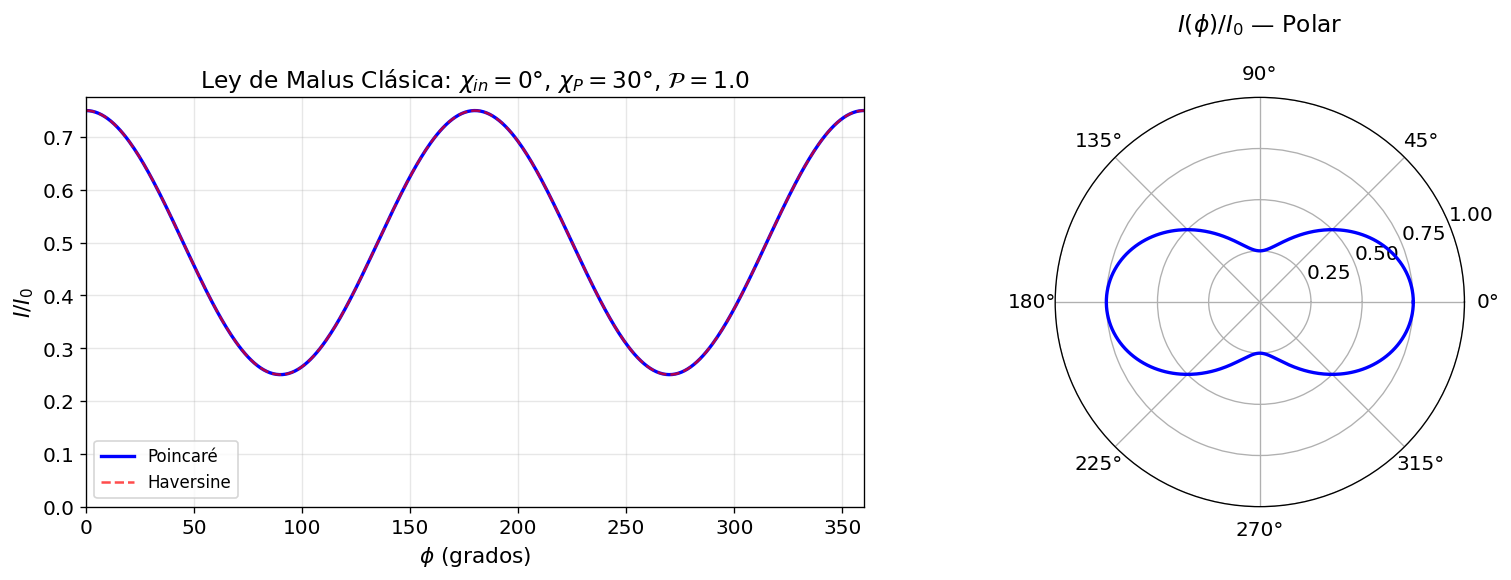

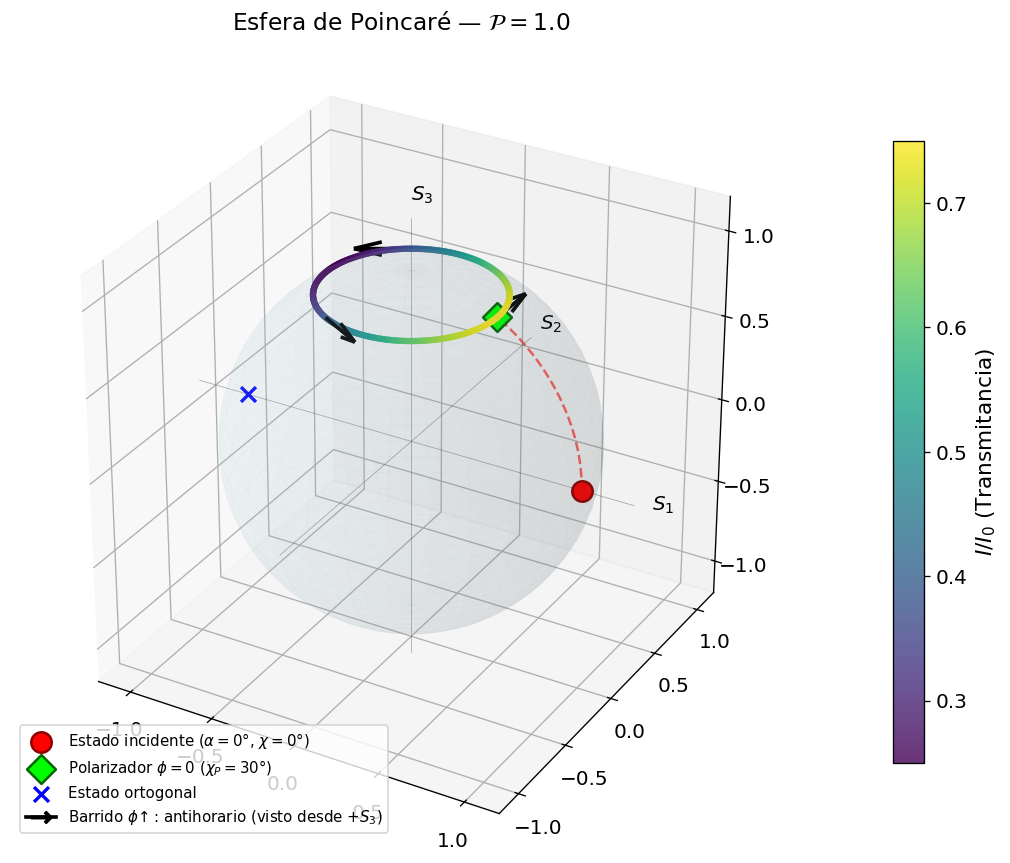

In [5]:
malus_eliptico = ClassicalMalus(alpha_in=0, chi_in=0, alpha_P=0,
                                 chi_P=np.radians(30), P_degree=1.0, I0=1.0)
malus_eliptico.plot_complete()

### 1.6 Caso 4: Caso general — Ambos elípticos, parcialmente coherente

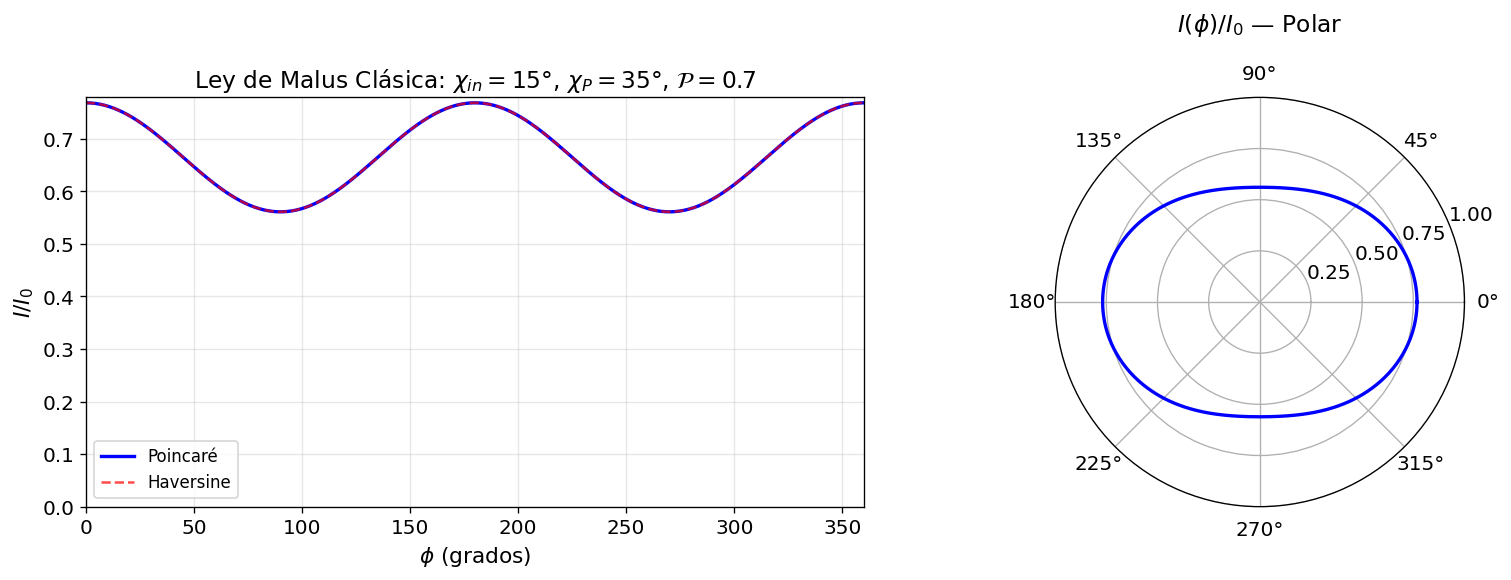

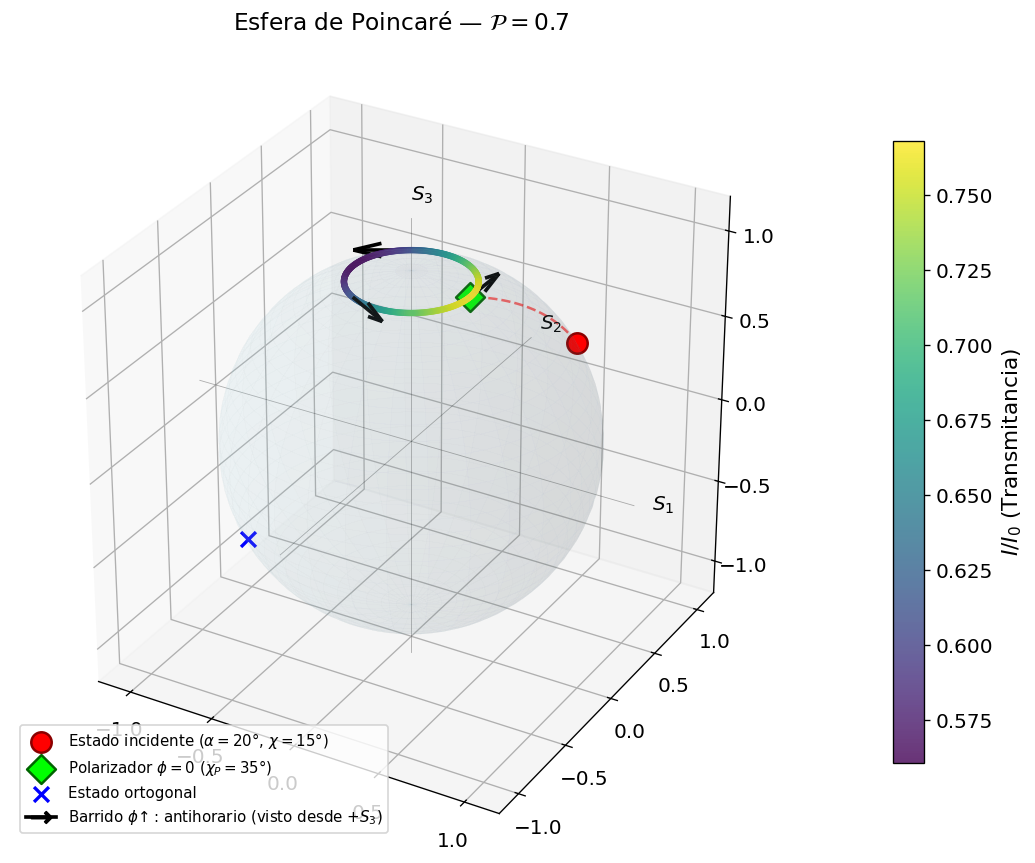

In [6]:
malus_general = ClassicalMalus(alpha_in=np.radians(20), chi_in=np.radians(15),
                                alpha_P=np.radians(0), chi_P=np.radians(35),
                                P_degree=0.7, I0=1.0)
malus_general.plot_complete()

### 1.7 Barrido de elipticidad del polarizador

Variamos $\chi_P$ de $0°$ (lineal) a $45°$ (circular) con haz horizontal completamente polarizado.

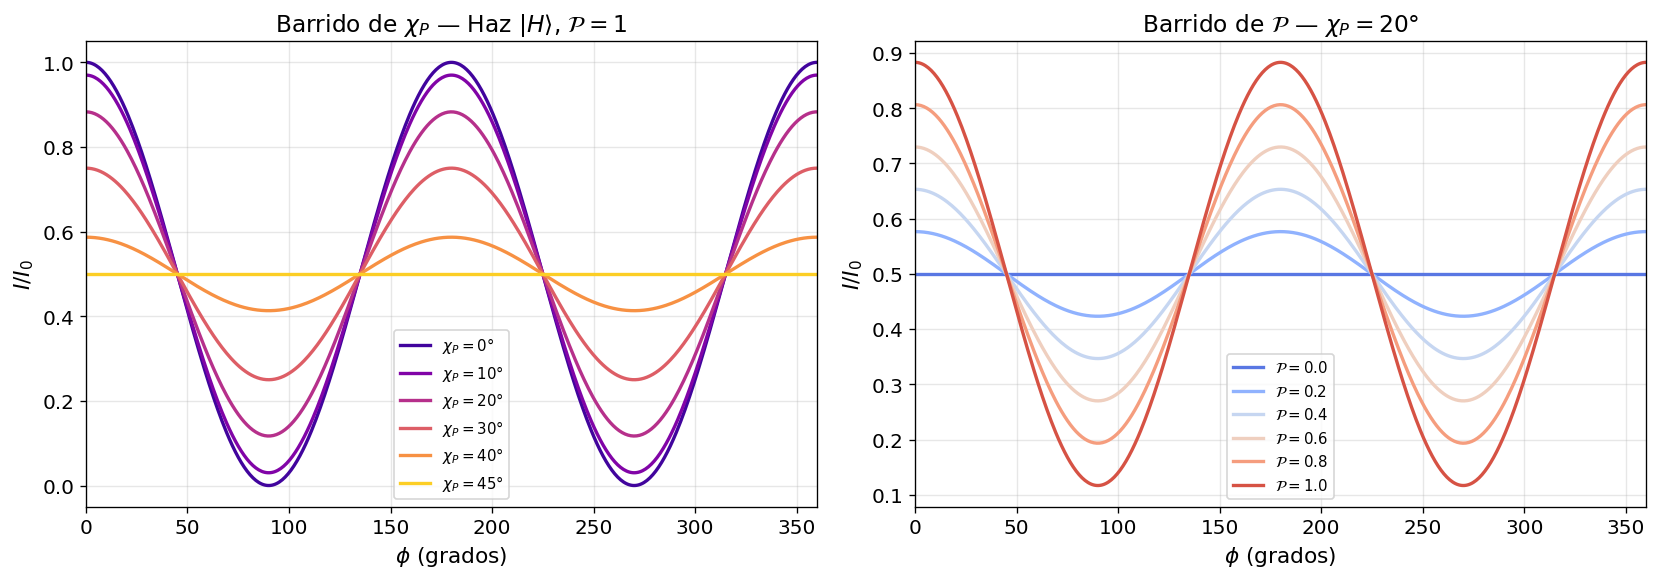

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
phi = np.linspace(0, 2*np.pi, 500)
chi_P_values = [0, 10, 20, 30, 40, 45]
colors = cm.plasma(np.linspace(0.1, 0.9, len(chi_P_values)))

for chi_val, color in zip(chi_P_values, colors):
    m = ClassicalMalus(chi_P=np.radians(chi_val), P_degree=1.0)
    I = m.intensity(phi) / m.I0
    axes[0].plot(np.degrees(phi), I, color=color, lw=2, label=rf'$\chi_P={chi_val}°$')

axes[0].set_xlabel(r'$\phi$ (grados)')
axes[0].set_ylabel(r'$I/I_0$')
axes[0].set_title(r'Barrido de $\chi_P$ — Haz $|H\rangle$, $\mathcal{P}=1$')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim(0, 360)

# Barrido de P
P_values = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
colors2 = cm.coolwarm(np.linspace(0.1, 0.9, len(P_values)))

for P_val, color in zip(P_values, colors2):
    m = ClassicalMalus(chi_P=np.radians(20), P_degree=P_val)
    I = m.intensity(phi) / m.I0
    axes[1].plot(np.degrees(phi), I, color=color, lw=2, label=rf'$\mathcal{{P}}={P_val}$')

axes[1].set_xlabel(r'$\phi$ (grados)')
axes[1].set_ylabel(r'$I/I_0$')
axes[1].set_title(r'Barrido de $\mathcal{P}$ — $\chi_P=20°$')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim(0, 360)

plt.tight_layout()
plt.show()

---
## 2. Régimen Cuántico: Ley de Malus para Qubits de Polarización

### 2.1 Marco teórico

El estado de polarización de un fotón individual constituye un **qubit**:

$$|\alpha,\chi\rangle = C_1|H\rangle + C_2|V\rangle$$

con $C_1 = \cos\alpha\cos\chi - i\sin\alpha\sin\chi$ y $C_2 = \sin\alpha\cos\chi + i\cos\alpha\sin\chi$.

La **probabilidad de detección** cuando un fotón $|\alpha,\chi\rangle$ pasa por un polarizador elíptico $|\alpha_P,\chi_P\rangle$ es:

$$\boxed{P(\phi) = \frac{1}{2}\left[1 + \cos 2\chi\cos 2\chi_P\cos 2\phi + \sin 2\chi\sin 2\chi_P\right]}$$

En el régimen cuántico, esta probabilidad se manifiesta **estadísticamente** sobre un ensamble de $M$ fotones idénticos:

$$\frac{N_{\text{det}}}{M} \xrightarrow{M\to\infty} P(\phi)$$

La esfera de Poincaré se identifica con la **esfera de Bloch**, y la probabilidad de detección es $P = \cos^2(\Theta/2)$.

In [8]:
class QuantumMalus:
    """
    Simula la ley de Malus cuántica para qubits de polarización (fotones individuales).
    
    Parámetros
    ----------
    alpha : float
        Ángulo de orientación del estado del fotón (rad).
    chi : float
        Ángulo de elipticidad del estado del fotón (rad).
    alpha_P : float
        Ángulo de orientación del polarizador (rad).
    chi_P : float
        Ángulo de elipticidad del polarizador (rad).
    N_photons : int
        Número de fotones en la simulación Monte Carlo.
    """
    
    def __init__(self, alpha=0.0, chi=0.0, alpha_P=0.0, chi_P=0.0, N_photons=10000):
        self.alpha = alpha
        self.chi = chi
        self.alpha_P = alpha_P
        self.chi_P = chi_P
        self.N_photons = N_photons
    
    def jones_vector(self, alpha, chi):
        """Vector de Jones para un estado elíptico."""
        C1 = np.cos(alpha)*np.cos(chi) - 1j*np.sin(alpha)*np.sin(chi)
        C2 = np.sin(alpha)*np.cos(chi) + 1j*np.cos(alpha)*np.sin(chi)
        return np.array([C1, C2])
    
    def bloch_vector(self, alpha, chi):
        """Vector de Bloch (= Stokes) para un estado puro."""
        return np.array([
            np.cos(2*chi) * np.cos(2*alpha),
            np.cos(2*chi) * np.sin(2*alpha),
            np.sin(2*chi)
        ])
    
    def probability(self, phi):
        """Probabilidad de detección teórica (Ley de Malus cuántica)."""
        return 0.5 * (1 + np.cos(2*self.chi)*np.cos(2*self.chi_P)*np.cos(2*phi)
                      + np.sin(2*self.chi)*np.sin(2*self.chi_P))
    
    def probability_amplitudes(self, phi):
        """Probabilidad calculada por producto interno de amplitudes."""
        psi_in = self.jones_vector(self.alpha, self.chi)
        psi_P = self.jones_vector(self.alpha_P + phi, self.chi_P)
        overlap = np.conj(psi_P) @ psi_in
        return np.abs(overlap)**2
    
    def monte_carlo(self, phi_array, seed=42):
        """
        Simulación Monte Carlo: para cada phi, simula N_photons fotones
        individuales y cuenta cuántos pasan el polarizador.
        """
        rng = np.random.default_rng(seed)
        counts = np.zeros_like(phi_array, dtype=float)
        
        for i, phi in enumerate(phi_array):
            p = self.probability(phi)
            # Cada fotón es un evento Bernoulli con probabilidad p
            detections = rng.random(self.N_photons) < p
            counts[i] = np.sum(detections)
        
        return counts / self.N_photons
    
    def trajectory_on_bloch(self, phi_array):
        """Trayectoria del estado del polarizador en la esfera de Bloch."""
        s1 = np.cos(2*self.chi_P) * np.cos(2*(self.alpha_P + phi_array))
        s2 = np.cos(2*self.chi_P) * np.sin(2*(self.alpha_P + phi_array))
        s3 = np.sin(2*self.chi_P) * np.ones_like(phi_array)
        return s1, s2, s3
    
    def plot_probability(self, N_points=200):
        """Grafica la probabilidad teórica y la simulación Monte Carlo."""
        phi = np.linspace(0, 2*np.pi, N_points)
        P_theory = np.array([self.probability(p) for p in phi])
        P_amplitudes = np.array([self.probability_amplitudes(p) for p in phi])
        
        # Monte Carlo con menos puntos
        phi_mc = np.linspace(0, 2*np.pi, 72)  # cada 5°
        P_mc = self.monte_carlo(phi_mc)
        
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        
        # Cartesiano
        axes[0].plot(np.degrees(phi), P_theory, 'b-', lw=2, label='Teoría (Poincaré)', zorder=3)
        axes[0].plot(np.degrees(phi), P_amplitudes, 'r--', lw=1.5, label='Amplitudes $|c_1|^2$', alpha=0.7)
        axes[0].scatter(np.degrees(phi_mc), P_mc, c='green', s=20, alpha=0.7, zorder=4,
                       label=f'Monte Carlo ($M={self.N_photons}$)')
        # Error bars (Poisson)
        sigma = np.sqrt(P_mc * (1 - P_mc) / self.N_photons)
        axes[0].fill_between(np.degrees(phi_mc), P_mc - 2*sigma, P_mc + 2*sigma,
                            color='green', alpha=0.15, label=r'$\pm 2\sigma$ (Poisson)')
        
        axes[0].set_xlabel(r'$\phi$ (grados)')
        axes[0].set_ylabel(r'$P(\phi)$')
        axes[0].set_title(
            rf'Ley de Malus Cuántica: $\chi={np.degrees(self.chi):.0f}°$, '
            rf'$\chi_P={np.degrees(self.chi_P):.0f}°$')
        axes[0].legend(fontsize=9)
        axes[0].grid(True, alpha=0.3)
        axes[0].set_xlim(0, 360)
        axes[0].set_ylim(-0.05, 1.05)
        
        # Polar
        ax_pol = fig.add_subplot(122, projection='polar')
        axes[1].set_visible(False)
        ax_pol.plot(phi, P_theory, 'b-', lw=2)
        ax_pol.scatter(phi_mc, P_mc, c='green', s=15, alpha=0.7)
        ax_pol.set_title(r'$P(\phi)$ — Polar', pad=20)
        
        plt.tight_layout()
        plt.show()
    
    def plot_bloch_sphere(self, N_points=500):
        """Grafica la esfera de Bloch con el estado del fotón y la trayectoria del analizador."""
        phi_arr = np.linspace(0, 2*np.pi, N_points)
        
        fig = plt.figure(figsize=(9, 9))
        ax = fig.add_subplot(111, projection='3d')
        
        # Esfera
        u = np.linspace(0, 2*np.pi, 60)
        v = np.linspace(0, np.pi, 40)
        xs = np.outer(np.cos(u), np.sin(v))
        ys = np.outer(np.sin(u), np.sin(v))
        zs = np.outer(np.ones_like(u), np.cos(v))
        ax.plot_surface(xs, ys, zs, alpha=0.06, color='lightyellow', edgecolor='khaki', linewidth=0.1)
        
        # Ejes
        ax.plot([-1.3,1.3],[0,0],[0,0], 'k-', lw=0.5, alpha=0.3)
        ax.plot([0,0],[-1.3,1.3],[0,0], 'k-', lw=0.5, alpha=0.3)
        ax.plot([0,0],[0,0],[-1.3,1.3], 'k-', lw=0.5, alpha=0.3)
        ax.text(1.4, 0, 0, r'$|H\rangle\!-\!|V\rangle$', fontsize=10, color='gray')
        ax.text(0, 1.4, 0, r'$|D\rangle\!-\!|A\rangle$', fontsize=10, color='gray')
        ax.text(0, 0, 1.4, r'$|R\rangle\!-\!|L\rangle$', fontsize=10, color='gray')
        
        # Estado del fotón (punto fijo)
        s_in = self.bloch_vector(self.alpha, self.chi)
        ax.scatter(*s_in, color='red', s=180, zorder=5, edgecolors='darkred', linewidth=2,
                   label=rf'Fotón $|\alpha={np.degrees(self.alpha):.0f}°,\chi={np.degrees(self.chi):.0f}°\rangle$')
        
        # Trayectoria del analizador
        s1_t, s2_t, s3_t = self.trajectory_on_bloch(phi_arr)
        P_traj = np.array([self.probability(p) for p in phi_arr])
        
        scatter = ax.scatter(s1_t, s2_t, s3_t, c=P_traj, cmap='magma',
                            s=8, alpha=0.8, zorder=3)
        
        # Sentido de barrido: flechas tangentes en la dirección de phi creciente
        sentido = add_sweep_arrows(ax, s1_t, s2_t, s3_t, phi_arr,
                                   color='black', n_arrows=3)
        
        # Analizador en phi=0
        s_P0 = self.bloch_vector(self.alpha_P, self.chi_P)
        ax.scatter(*s_P0, color='lime', s=180, zorder=5, marker='D', edgecolors='darkgreen', linewidth=2,
                   label=rf'Analizador $\phi=0$ ($\chi_P={np.degrees(self.chi_P):.0f}°$)')
        
        # Estado ortogonal (P=0)
        s_ort = -s_in
        ax.scatter(*s_ort, color='blue', s=100, zorder=5, marker='x', linewidth=2.5,
                   label=r'Estado ortogonal ($P=0$)')
        
        # Geodésica
        t = np.linspace(0, 1, 100)
        geodesic = np.outer(1-t, s_in) + np.outer(t, s_P0)
        norms = np.linalg.norm(geodesic, axis=1, keepdims=True)
        geodesic = geodesic / norms
        ax.plot(geodesic[:,0], geodesic[:,1], geodesic[:,2], 'r--', lw=1.5, alpha=0.5)
        
        cbar = plt.colorbar(scatter, ax=ax, shrink=0.6, pad=0.1)
        cbar.set_label(r'$P(\phi)$ (Probabilidad de detección)')
        
        ax.set_title('Esfera de Bloch — Qubit de Polarización', fontsize=14, pad=20)
        # Leyenda: añadimos una entrada con el sentido de barrido de phi
        handles, labels = ax.get_legend_handles_labels()
        handles.append(Line2D([0], [0], color='black', lw=2.2, marker=r'$\rightarrow$',
                              markersize=12, linestyle='-'))
        labels.append(rf'Barrido $\phi\!\uparrow$: {sentido} (visto desde $+S_3$)')
        ax.legend(handles, labels, loc='lower left', fontsize=9)
        ax.set_xlim([-1.2, 1.2])
        ax.set_ylim([-1.2, 1.2])
        ax.set_zlim([-1.2, 1.2])
        ax.set_box_aspect([1,1,1])
        
        plt.tight_layout()
        plt.show()
    
    def plot_complete(self, N_points=500):
        """Genera ambas gráficas."""
        self.plot_probability(min(N_points, 200))
        self.plot_bloch_sphere(N_points)

### 2.2 Caso 1: Malus cuántica clásica ($\chi=\chi_P=0$)

Fotón lineal horizontal sobre polarizador lineal: $P = \cos^2\phi$.
Los puntos verdes son la simulación Monte Carlo de $M=10000$ fotones individuales.

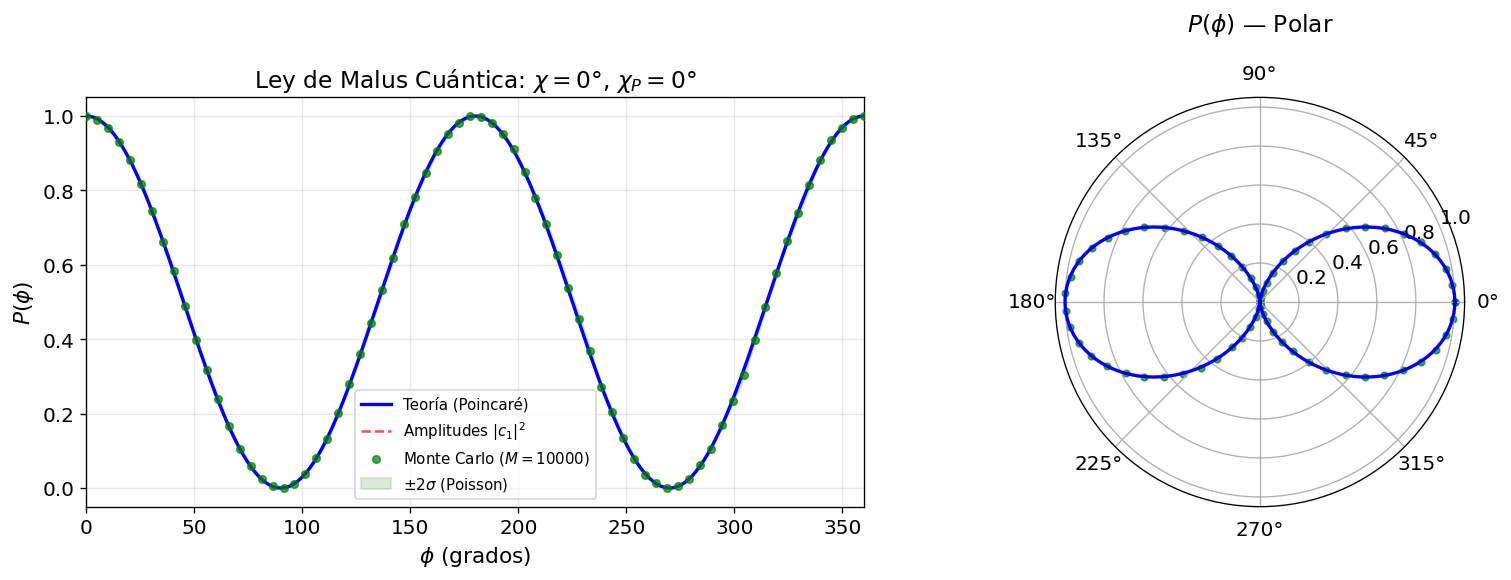

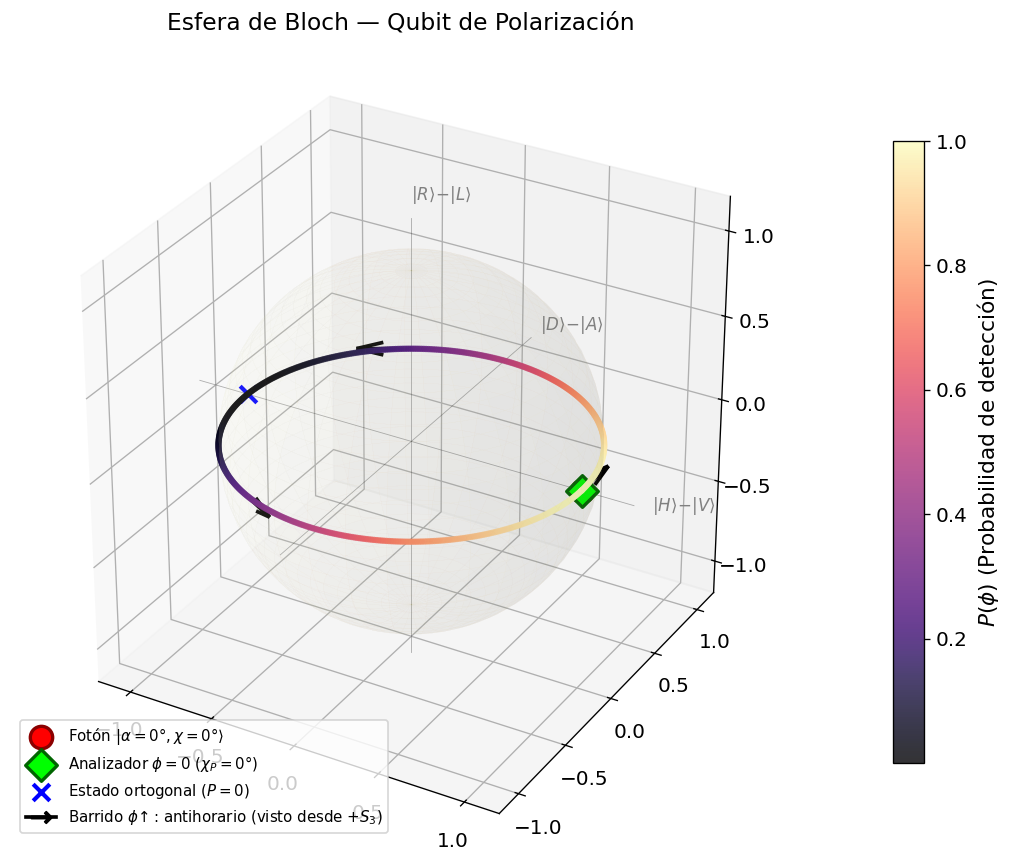

In [9]:
qm_lineal = QuantumMalus(alpha=0, chi=0, alpha_P=0, chi_P=0, N_photons=10000)
qm_lineal.plot_complete()

### 2.3 Caso 2: Fotón lineal sobre polarizador elíptico ($\chi=0$, $\chi_P=30°$)

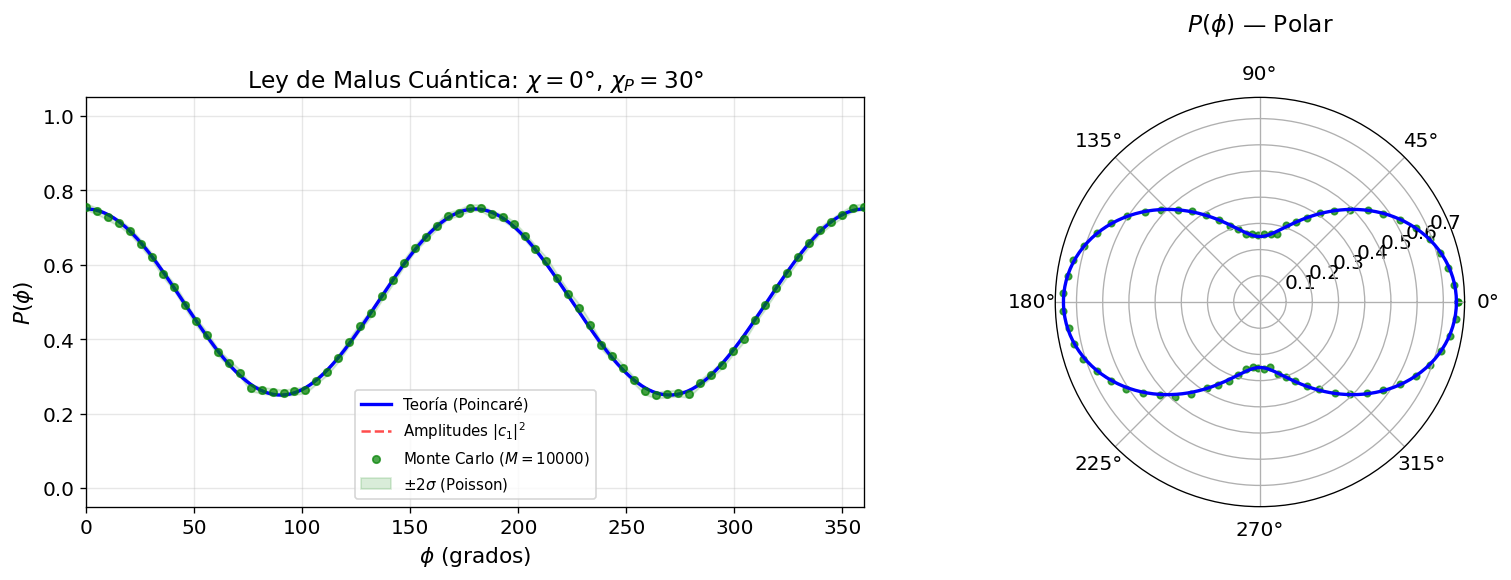

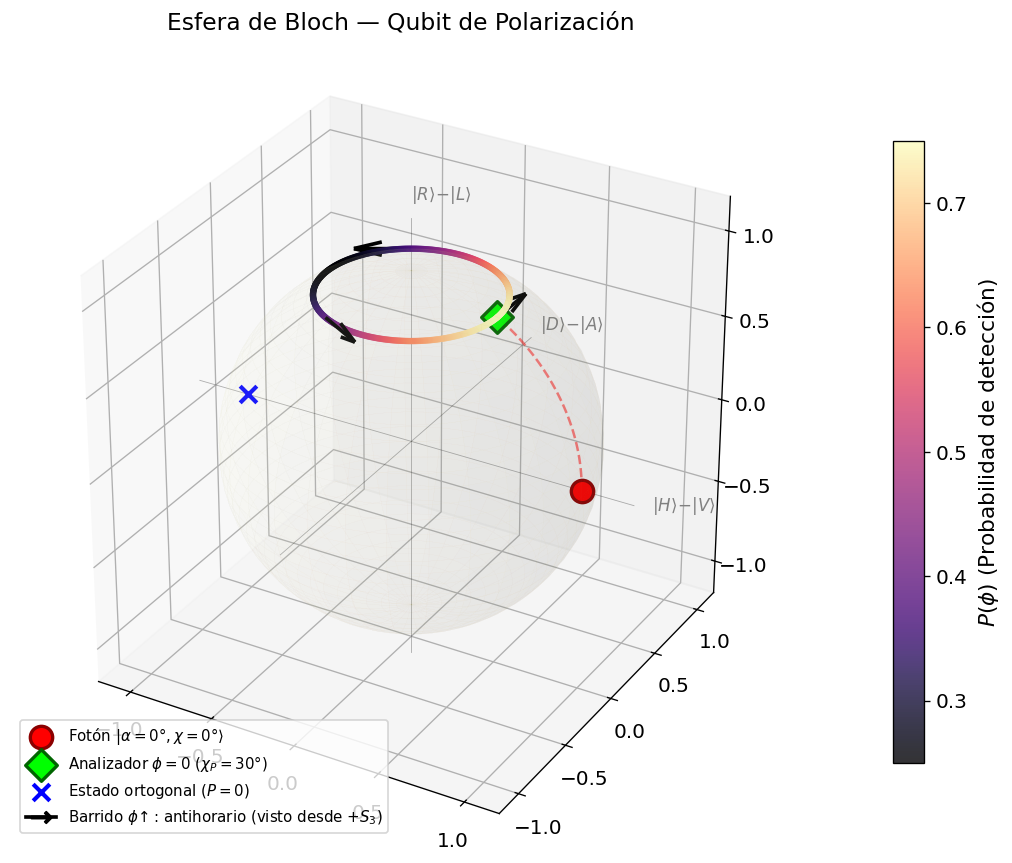

In [10]:
qm_eliptico = QuantumMalus(alpha=0, chi=0, alpha_P=0, chi_P=np.radians(30), N_photons=10000)
qm_eliptico.plot_complete()

### 2.4 Caso 3: Fotón circular sobre polarizador circular ($\chi=\chi_P=45°$)

La probabilidad es constante $P=1$ (fotón y polarizador idénticos), independiente de $\phi$.

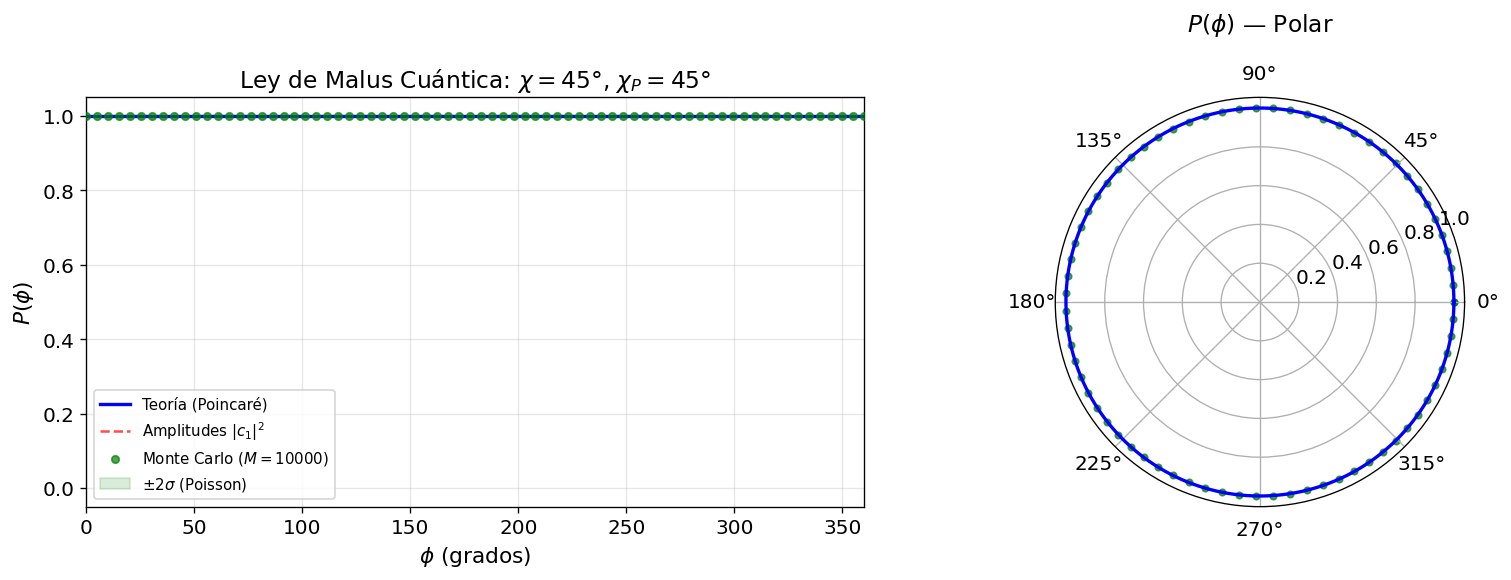

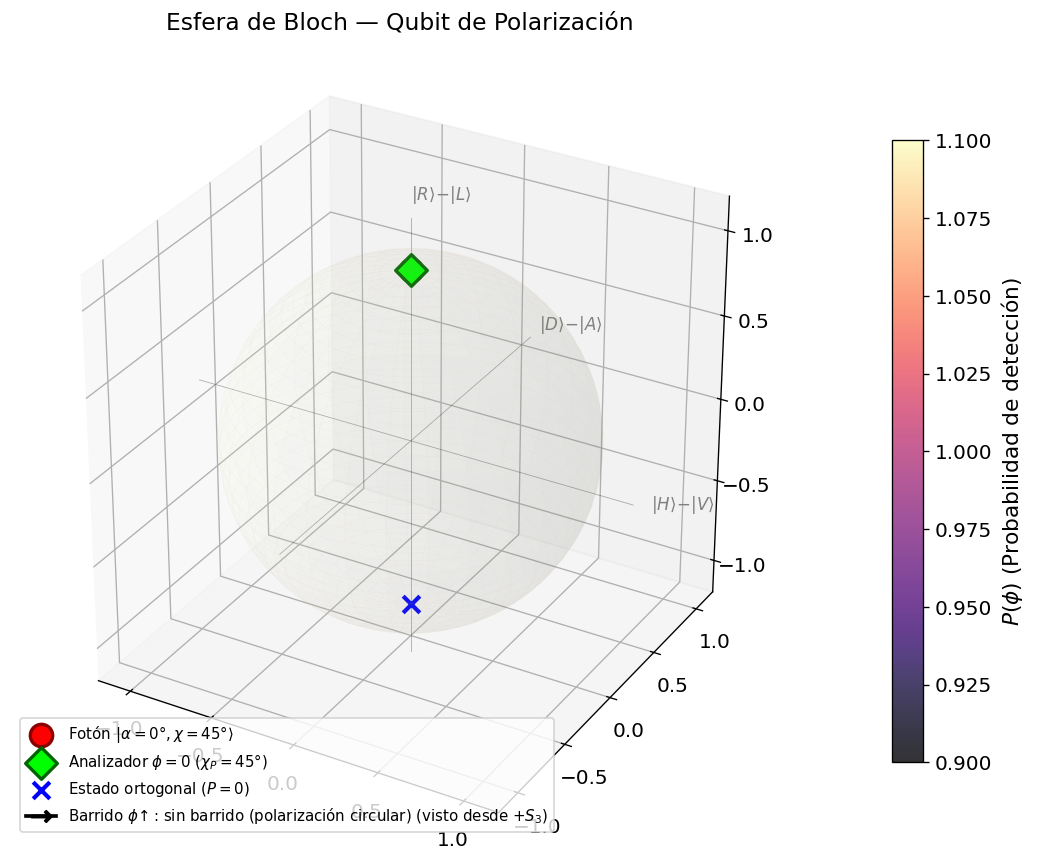

In [11]:
qm_circular = QuantumMalus(alpha=0, chi=np.radians(45), alpha_P=0,
                            chi_P=np.radians(45), N_photons=10000)
qm_circular.plot_complete()

### 2.5 Caso 4: Caso general — Ambos elípticos

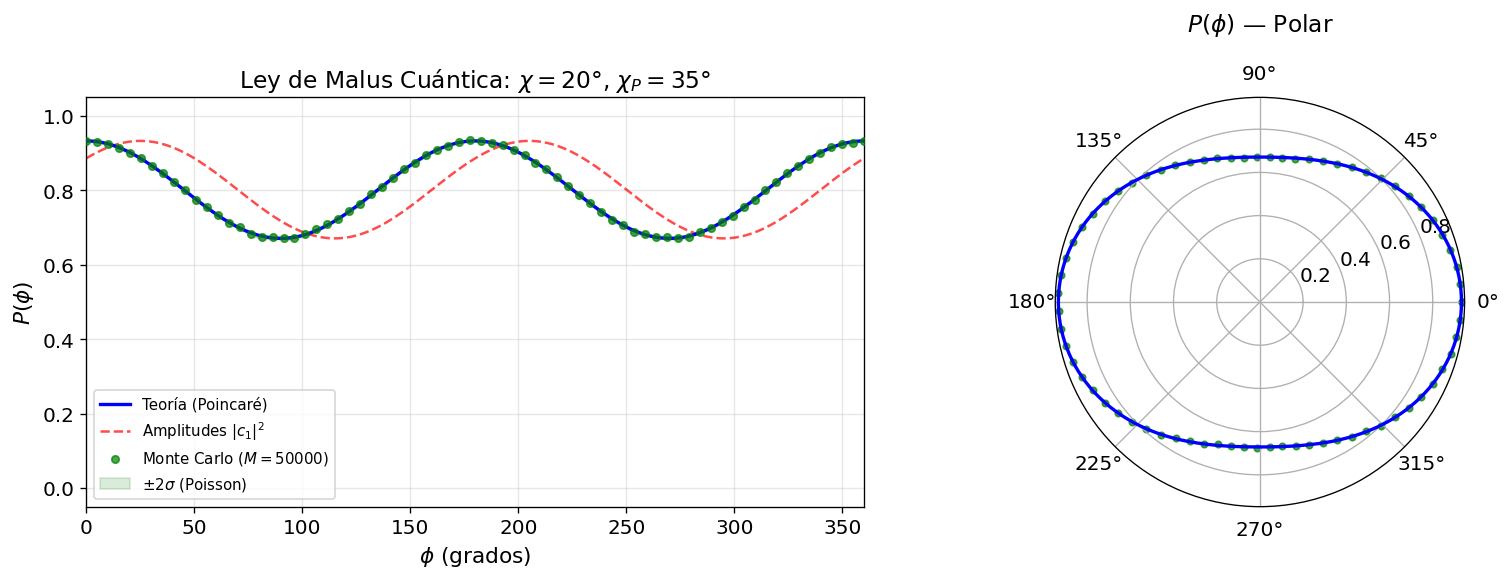

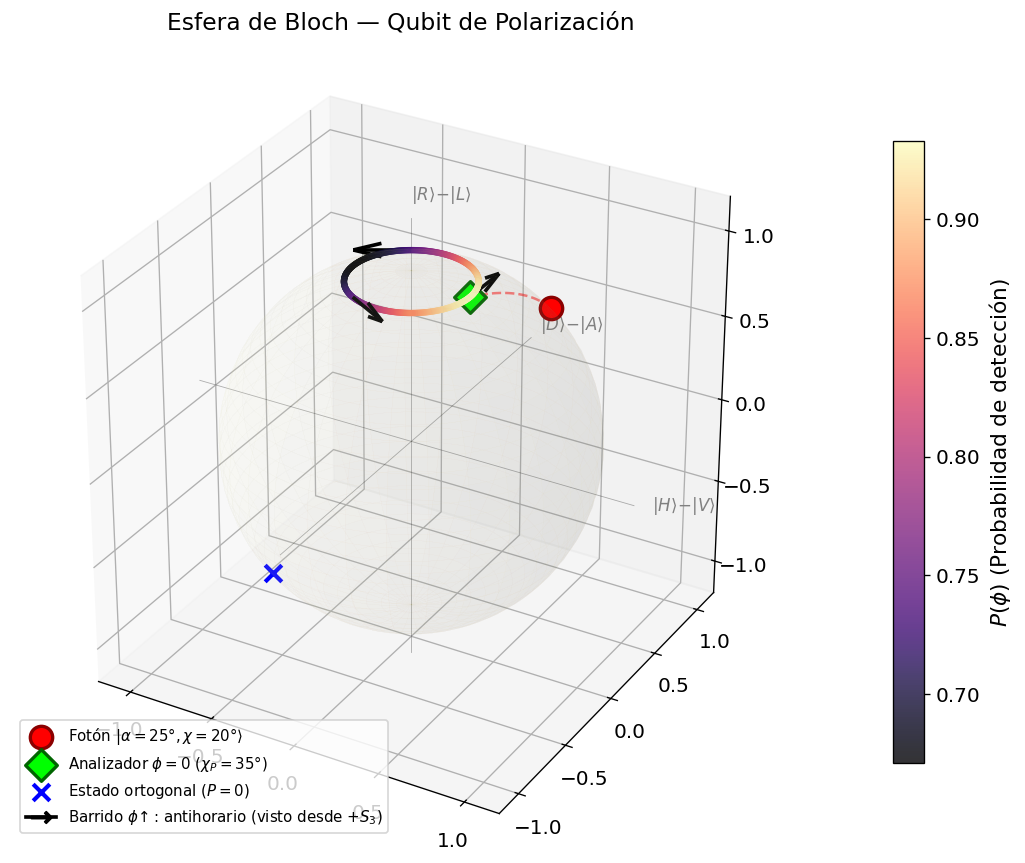

In [12]:
qm_general = QuantumMalus(alpha=np.radians(25), chi=np.radians(20),
                           alpha_P=np.radians(0), chi_P=np.radians(35),
                           N_photons=50000)
qm_general.plot_complete()

### 2.6 Convergencia Monte Carlo: efecto del número de fotones

Demostramos cómo la estadística de Poisson converge a la predicción teórica conforme aumenta $M$.

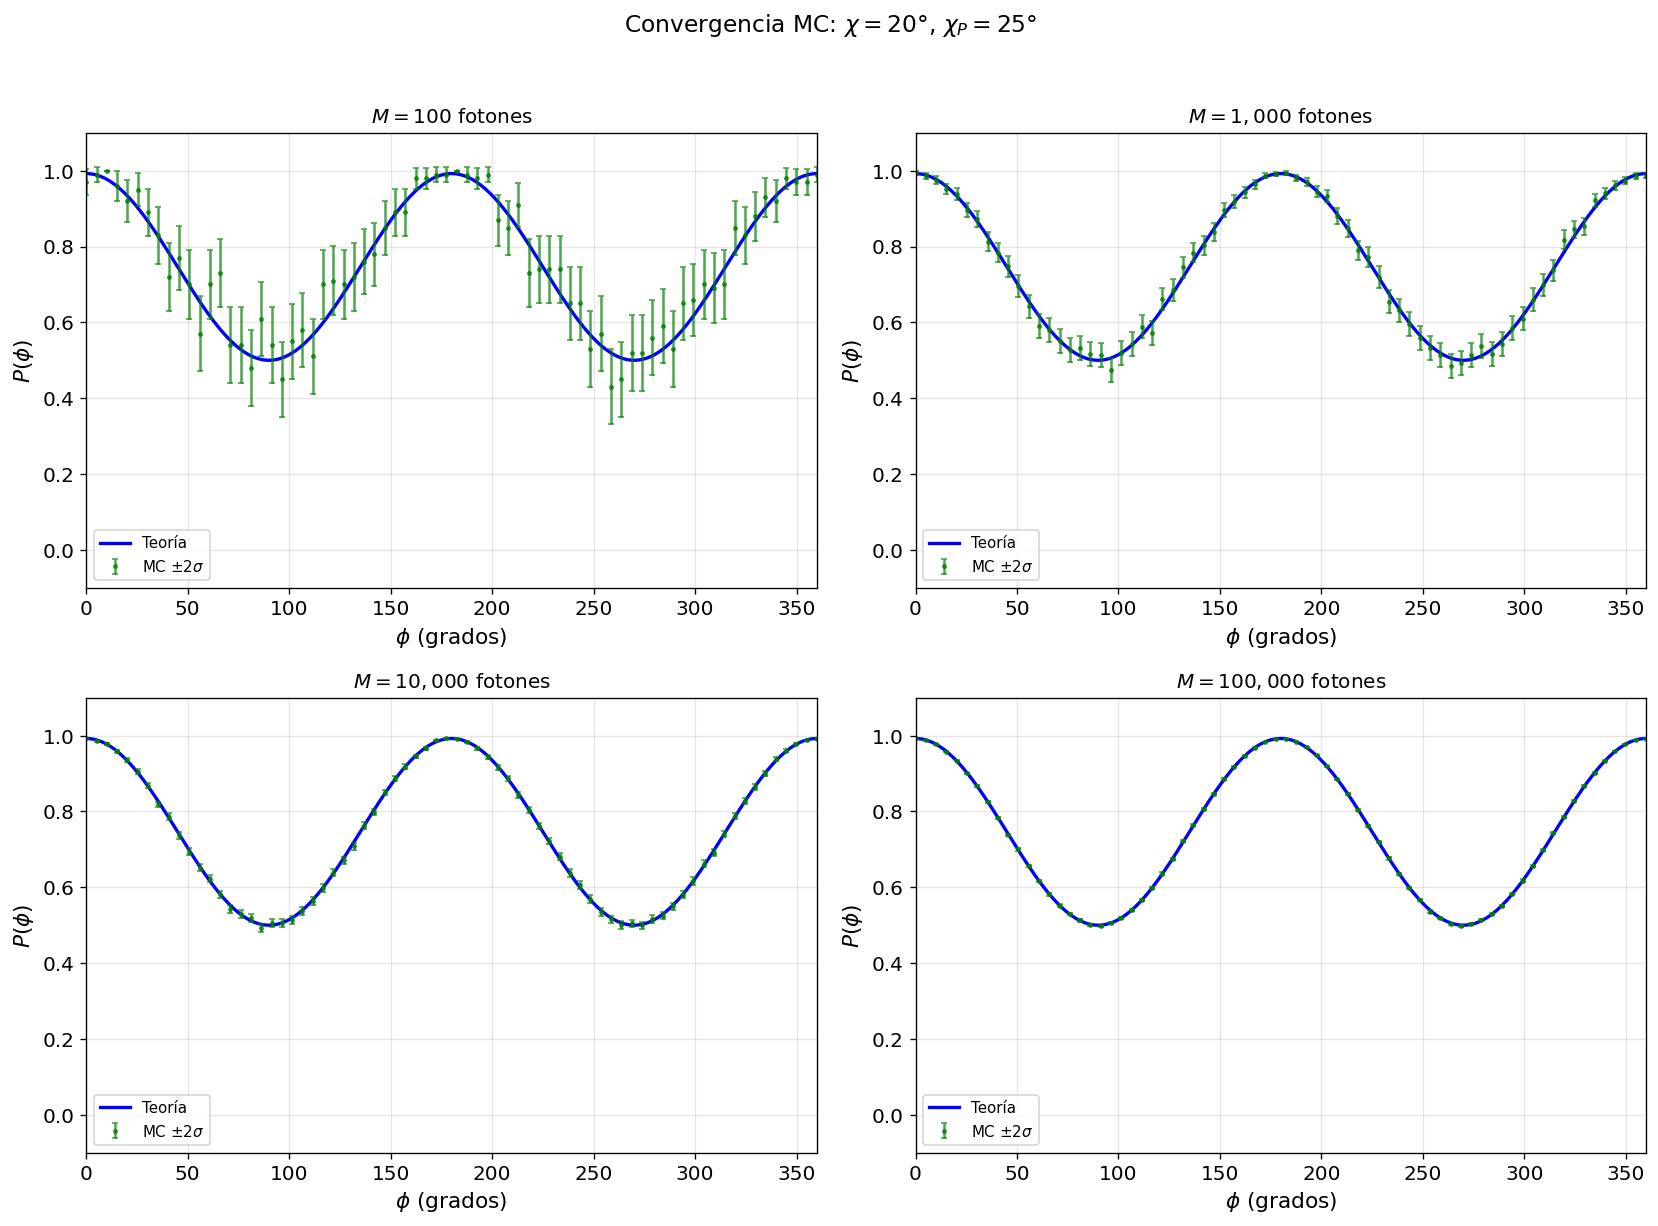

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
N_values = [100, 1000, 10000, 100000]
phi_mc = np.linspace(0, 2*np.pi, 72)
phi_theory = np.linspace(0, 2*np.pi, 500)

for ax, N in zip(axes.flat, N_values):
    qm = QuantumMalus(alpha=np.radians(10), chi=np.radians(20),
                      chi_P=np.radians(25), N_photons=N)
    P_th = np.array([qm.probability(p) for p in phi_theory])
    P_mc = qm.monte_carlo(phi_mc, seed=N)
    sigma = np.sqrt(P_mc * (1-P_mc) / N)
    
    ax.plot(np.degrees(phi_theory), P_th, 'b-', lw=2, label='Teoría')
    ax.errorbar(np.degrees(phi_mc), P_mc, yerr=2*sigma, fmt='g.', ms=4,
                capsize=2, alpha=0.7, label=rf'MC $\pm 2\sigma$')
    ax.set_title(rf'$M = {N:,}$ fotones', fontsize=12)
    ax.set_xlabel(r'$\phi$ (grados)')
    ax.set_ylabel(r'$P(\phi)$')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, 360)
    ax.set_ylim(-0.1, 1.1)

plt.suptitle(r'Convergencia MC: $\chi=20°$, $\chi_P=25°$', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 2.7 Barrido cuántico de $\chi_P$: de lineal a circular

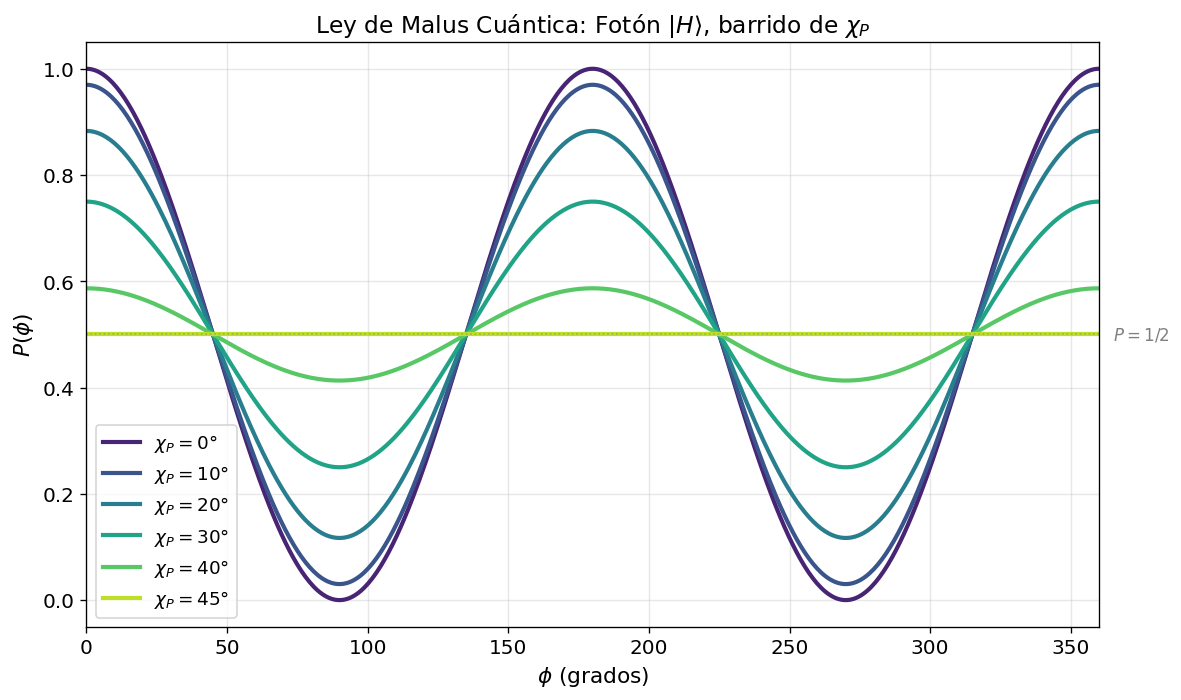

In [14]:
fig, ax = plt.subplots(figsize=(10, 6))
phi = np.linspace(0, 2*np.pi, 500)
chi_P_vals = [0, 10, 20, 30, 40, 45]
colors = cm.viridis(np.linspace(0.1, 0.9, len(chi_P_vals)))

for chi_val, color in zip(chi_P_vals, colors):
    qm = QuantumMalus(alpha=0, chi=0, chi_P=np.radians(chi_val))
    P = np.array([qm.probability(p) for p in phi])
    ax.plot(np.degrees(phi), P, color=color, lw=2.5, label=rf'$\chi_P={chi_val}°$')

ax.set_xlabel(r'$\phi$ (grados)', fontsize=13)
ax.set_ylabel(r'$P(\phi)$', fontsize=13)
ax.set_title(r'Ley de Malus Cuántica: Fotón $|H\rangle$, barrido de $\chi_P$', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 360)
ax.set_ylim(-0.05, 1.05)
ax.axhline(0.5, color='gray', ls=':', lw=1, alpha=0.5)
ax.text(365, 0.5, r'$P=1/2$', fontsize=10, color='gray', va='center')

plt.tight_layout()
plt.show()

---
## 3. Comparación Clásica vs Cuántica

La ley de Malus generalizada tiene la **misma forma funcional** en ambos regímenes:

| Régimen | Cantidad | Expresión |
|---------|----------|----------|
| Clásico | Intensidad $I$ | $\frac{I_0}{2}[1 + \mathcal{P}(\cos 2\chi_{in}\cos 2\chi_P\cos 2\phi + \sin 2\chi_{in}\sin 2\chi_P)]$ |
| Cuántico | Probabilidad $P$ | $\frac{1}{2}[1 + \cos 2\chi\cos 2\chi_P\cos 2\phi + \sin 2\chi\sin 2\chi_P]$ |

La correspondencia es: $I = N\hbar\omega \cdot P$, con $\mathcal{P}=1$ para fotones individuales.

Ambas se escriben de forma compacta como funciones de la distancia en la esfera:

$$I = \frac{I_0}{2}[1 + \mathcal{P}\cos\Theta_{\text{Poincaré}}], \qquad P = \cos^2\frac{\Theta_{\text{Bloch}}}{2}$$

<>:32: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:32: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
/var/folders/0z/vldj22112lz3fhllvsqpnxkw0000gn/T/ipykernel_41015/1466334926.py:32: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  plt.suptitle('Correspondencia Clásica–Cuántica ($\mathcal{P}=1$)', fontsize=14, y=1.02)


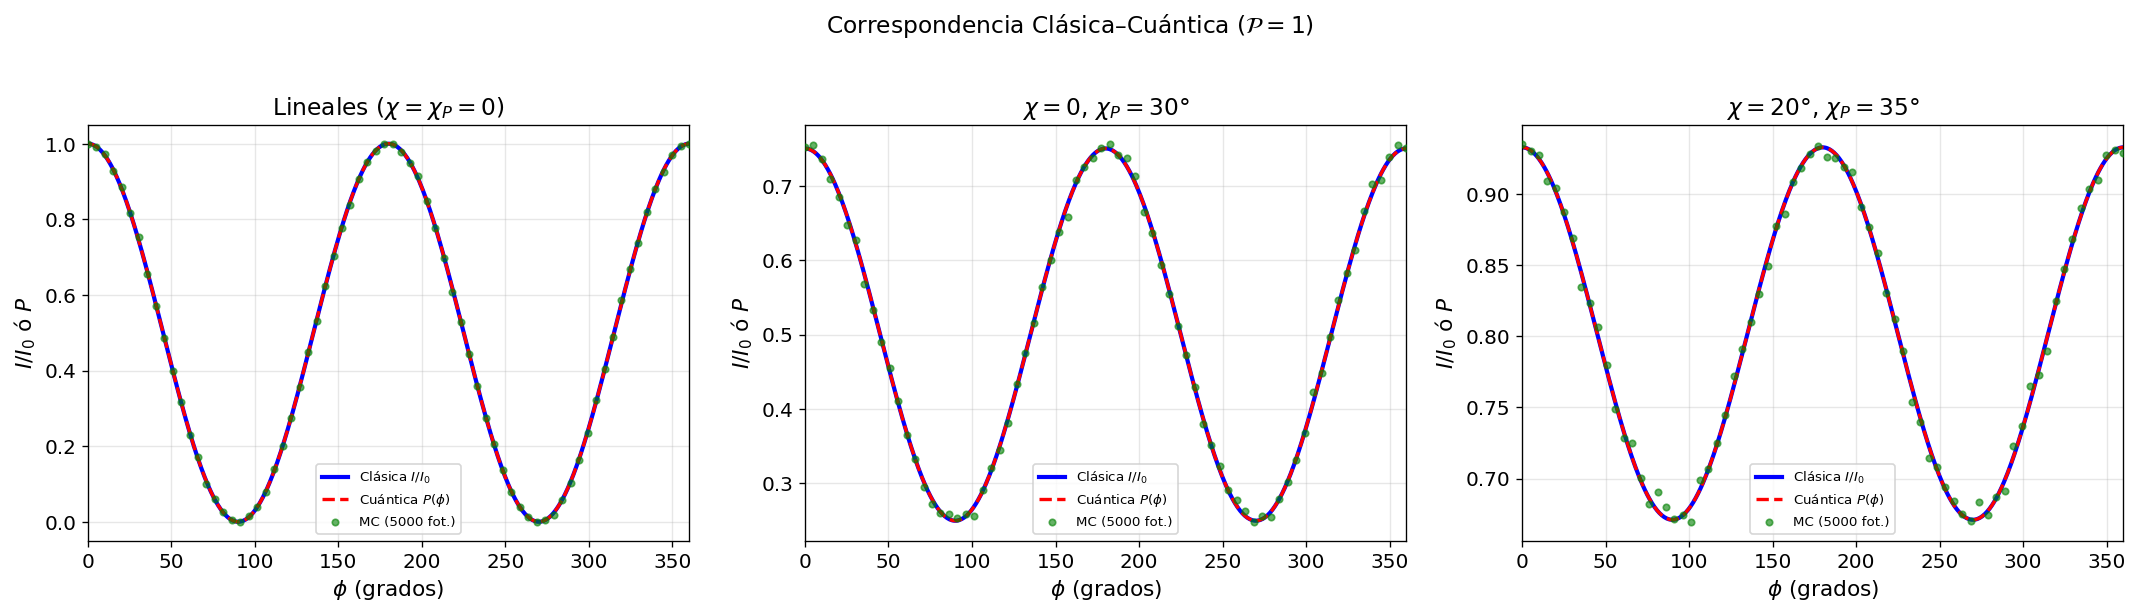

In [15]:
# Comparación directa: mismos parámetros, clásico vs cuántico
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
phi = np.linspace(0, 2*np.pi, 500)

params = [
    {'chi_in': 0,  'chi_P': 0,  'label': r'Lineales ($\chi=\chi_P=0$)'},
    {'chi_in': 0,  'chi_P': 30, 'label': r'$\chi=0$, $\chi_P=30°$'},
    {'chi_in': 20, 'chi_P': 35, 'label': r'$\chi=20°$, $\chi_P=35°$'},
]

for ax, p in zip(axes, params):
    cm_obj = ClassicalMalus(chi_in=np.radians(p['chi_in']), chi_P=np.radians(p['chi_P']), P_degree=1.0)
    qm_obj = QuantumMalus(chi=np.radians(p['chi_in']), chi_P=np.radians(p['chi_P']), N_photons=5000)
    
    I_cl = cm_obj.intensity(phi) / cm_obj.I0
    P_qu = np.array([qm_obj.probability(pp) for pp in phi])
    
    phi_mc = np.linspace(0, 2*np.pi, 72)
    P_mc = qm_obj.monte_carlo(phi_mc)
    
    ax.plot(np.degrees(phi), I_cl, 'b-', lw=2.5, label=r'Clásica $I/I_0$')
    ax.plot(np.degrees(phi), P_qu, 'r--', lw=2, label=r'Cuántica $P(\phi)$')
    ax.scatter(np.degrees(phi_mc), P_mc, c='green', s=15, alpha=0.6, zorder=4, label='MC (5000 fot.)')
    
    ax.set_xlabel(r'$\phi$ (grados)')
    ax.set_ylabel(r'$I/I_0$ ó $P$')
    ax.set_title(p['label'])
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, 360)

plt.suptitle('Correspondencia Clásica–Cuántica ($\mathcal{P}=1$)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()